In [2]:
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot(title, label, x, result, expected, interval=None):
    if interval is not None:
        plt.axis([-10.1, 10.1, min(result), max(result)])
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))

def mxae(result, expected):
    return np.max(np.abs(np.array(result) - np.array(expected)))

def by_interval(df):
    for interval, group in df.groupby('Interval'):
        display(group)

In [56]:
""" Core methods """

# Until Codon Jupyter is fixed: Read the data from files
show_plots = False

dump_folder = "dump"
dump_files = [
    "decor_trig",
    "decor",
    "fourier",
    "cheby",
    "taylor"
    ]
nbit_fs = [64]
intervals_count = 1
cps = [0, 1]
exclude = ["sinh", "cosh", "tanh"]

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'MXAE': [],
    'Runtime (avg)': [],
    'Runtime (std)': [],
    'Partitions count': [],
    'Truncations count': []
    }

df_waves = {
    'x': [],
    'Method': [],
    'Expected': [],
    'Result': []
    }

for cp in cps:
    df_data[f'Bytes sent CP{cp}'] = []
    df_data[f'Requests sent CP{cp}'] = []

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for i in range(intervals_count):
            for cp in cps:
                try:
                    with open(f"{dump_folder}/{dump_file}_{i}_{nbit_f}_CP{cp}.p", "rb") as f:
                        data = pickle.load(f)
                        x = data['x']
                        interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
                        for k, v in data.items():
                            if not k.endswith('_result'):
                                continue

                            skip = False
                            for exclude_item in exclude:
                                if exclude_item in k:
                                    skip = True
                                    break
                            
                            if skip:
                                continue

                            k = k.replace('_result', '')
                            expected = data[f"{k}_expected"]

                            runtime_avg = round(data[f"{k}_time"][0], 5)
                            runtime_std = round(data[f"{k}_time"][1], 5)
                            bytes_sent = int(data[f"{k}_bytes_sent"][0])
                            send_requests = int(data[f"{k}_send_requests"][0])
                            partitions_count = int(data[f"{k}_partitions_count"][0])
                            truncations_count = int(data[f"{k}_truncations_count"][0])
                            
                            if cp == 1:
                                df_data['Method'].append(f"{k}_{nbit_f}")
                                df_data['Interval'].append(interval)
                                df_data['MAE'].append(mae(v, expected))
                                df_data['MXAE'].append(mxae(v, expected))

                                df_data['Runtime (avg)'].append(runtime_avg)
                                df_data['Runtime (std)'].append(runtime_std)
                                df_data['Partitions count'].append(partitions_count)
                                df_data['Truncations count'].append(truncations_count)

                            df_data[f'Bytes sent CP{cp}'].append(bytes_sent)
                            df_data[f'Requests sent CP{cp}'].append(send_requests)

                            if cp == 1 and interval == "(-9.42, 9.42)":
                                df_waves['x'].append(x)
                                df_waves['Method'].append(f"{k}_{nbit_f}")
                                df_waves['Expected'].append(expected)
                                df_waves['Result'].append(v)

                            if show_plots and cp == 1:
                                plot(f"{k} {nbit_f} frac bits on {interval}", k, x, v, expected)
                except FileNotFoundError:
                    print(f"Could not find {dump_folder}/{dump_file}_{i}_{nbit_f}.p")

df = pd.DataFrame(df_data)

In [57]:
if df.empty:
    raise ValueError("DataFrame is empty")

display_methods = [
    "sin_", "cos_", "tan_", "cot", "exp",
    "sigmoid", "sinh", "cosh", "tanh",
    "sqrt", "log", "mul_inv", "polynomial"]

for method in display_methods:
    display(by_interval(df[df['Method'].str.contains(method)].sort_values(by='MAE')))

,Method,Interval,MAE,MXAE,Runtime (avg),Runtime (std),Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
1,decor_sin_64,"(-20.0, 20.0)",6.440248e-16,3.594347e-15,0.00441,0.00150,1,0,64064,8,21354,2
163,chebyshev_50_sin_clenshaw_64,"(-20.0, 20.0)",3.737191e-15,3.907985e-14,0.35025,0.00410,50,52,2466464,308,1633632,204
171,chebyshev_60_sin_clenshaw_64,"(-20.0, 20.0)",5.405761e-15,8.437695e-14,0.42636,0.00293,60,62,2946944,368,1953952,244
132,chebyshev_65_sin_clenshaw_64,"(-20.0, 20.0)",5.951522e-15,1.342260e-13,0.47577,0.00305,65,67,3187184,398,2114112,264
162,chebyshev_70_sin_clenshaw_64,"(-20.0, 20.0)",8.068747e-15,2.700062e-13,0.51815,0.00394,70,72,3427424,428,2274272,284
109,chebyshev_55_sin_clenshaw_64,"(-20.0, 20.0)",1.021898e-14,2.028377e-13,0.38711,0.00402,55,57,2706704,338,1793792,224
90,chebyshev_45_sin_clenshaw_64,"(-20.0, 20.0)",6.154531e-14,1.846301e-13,0.31676,0.00242,45,47,2226224,278,1473472,184
158,chebyshev_40_sin_clenshaw_64,"(-20.0, 20.0)",3.421156e-10,5.824827e-10,0.28079,0.00251,40,42,1985984,248,1313312,164
157,chebyshev_35_sin_clenshaw_64,"(-20.0, 20.0)",6.555618e-08,1.758356e-07,0.23858,0.00108,35,37,1745744,218,1153152,144
148,chebyshev_30_sin_clenshaw_64,"(-20.0, 20.0)",6.190026e-05,1.134958e-04,0.20399,0.00247,30,32,1505504,188,992992,124


None

,Method,Interval,MAE,MXAE,Runtime (avg),Runtime (std),Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
0,decor_cos_64,"(-20.0, 20.0)",5.991752e-16,3.136380e-15,0.00332,0.00000,1,1,64064,8,16016,2
117,chebyshev_50_cos_clenshaw_64,"(-20.0, 20.0)",2.877356e-15,2.076117e-14,0.35314,0.00231,50,52,2466464,308,1633632,204
121,chebyshev_60_cos_clenshaw_64,"(-20.0, 20.0)",3.620375e-15,4.229950e-14,0.42845,0.00310,60,62,2946944,368,1953952,244
137,chebyshev_65_cos_clenshaw_64,"(-20.0, 20.0)",4.043280e-15,5.850875e-14,0.47528,0.00311,65,67,3187184,398,2114112,264
122,chebyshev_70_cos_clenshaw_64,"(-20.0, 20.0)",4.864166e-15,1.240119e-13,0.51947,0.00170,70,72,3427424,428,2274272,284
101,chebyshev_55_cos_clenshaw_64,"(-20.0, 20.0)",5.469139e-15,8.787415e-14,0.38943,0.00528,55,57,2706704,338,1793792,224
106,chebyshev_45_cos_clenshaw_64,"(-20.0, 20.0)",2.711928e-13,4.510836e-13,0.31539,0.00242,45,47,2226224,278,1473472,184
146,chebyshev_40_cos_clenshaw_64,"(-20.0, 20.0)",8.858140e-11,2.457943e-10,0.27894,0.00266,40,42,1985984,248,1313312,164
114,chebyshev_35_cos_clenshaw_64,"(-20.0, 20.0)",2.178732e-07,3.810601e-07,0.23869,0.00207,35,37,1745744,218,1153152,144
143,chebyshev_30_cos_clenshaw_64,"(-20.0, 20.0)",2.244094e-05,5.670996e-05,0.20498,0.00333,30,32,1505504,188,992992,124


None

None

...

None

None

None

,Method,Interval,MAE,MXAE,Runtime (avg),Runtime (std),Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
4,decor_polynomial_64,"(-20.0, 20.0)",4.078142e-12,2.910383e-11,0.03965,0.00171,28,3,344528,50,312704,64


None

In [9]:
""" E2E apps """

# Until Codon Jupyter is fixed: Read the data from files
dump_folder = "dump"
dump_files = [
    # "log_reg",
    # "mnist",
    # "dti",
    # "gwas",
    # "siren",
    "medmnist"
    ]
nbit_fs = [64]
cps = [0, 1]

df_data = {
    'Method': [],
    'Accuracy': [],
    'Loss': [],
    'Runtime': [],
    'Bytes sent': [],
    'Requests sent': [],
    'Partitions count': [],
    'Truncations count': []
    }

df_gwas_betas = {
    'Method': [],
    'Betas': []
    }

df_siren_images = {
    'Method': [],
    'Images': []
    }

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for cp in cps:
            if cp == 0:
                continue
            
            try:
                with open(f"{dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p", "rb") as f:
                    data = pickle.load(f)
                    for k, v in data.items():
                        if "gwas_plaintext" in k and "_betas" in k:
                            df_gwas_betas['Method'].append(f"{k}_{nbit_f}")
                            df_gwas_betas['Betas'].append(data[k])
                        if not k.endswith('_time'):
                            continue

                        k = k.replace('_time', '')
                        accuracy = np.array(data.get(f"{k}_accuracy", [-1])).mean()
                        loss = np.array(data.get(f"{k}_loss", [-1])).mean()
                        runtime = round(data.get(f"{k}_time", [-1])[0], 5)
                        bytes_sent = int(data.get(f"{k}_bytes_sent", [-1])[0])
                        send_requests = int(data.get(f"{k}_send_requests", [-1])[0])
                        partitions_count = int(data.get(f"{k}_partitions_count", [-1])[0])
                        truncations_count = int(data.get(f"{k}_truncations_count", [-1])[0])

                        df_data['Method'].append(f"{k}_{nbit_f}")
                        
                        df_data['Accuracy'].append(accuracy)
                        df_data['Loss'].append(loss)
                        df_data['Runtime'].append(runtime)
                        df_data['Bytes sent'].append(bytes_sent)
                        df_data['Requests sent'].append(send_requests)
                        df_data['Partitions count'].append(partitions_count)
                        df_data['Truncations count'].append(truncations_count)

                        if dump_file == "gwas":
                            df_gwas_betas['Method'].append(f"{k}_betas_{nbit_f}")
                            df_gwas_betas['Betas'].append(data[f"{k}_betas"])
                        if dump_file == "siren":
                            df_siren_images['Method'].append(f"{k}_img_{nbit_f}")
                            df_siren_images['Images'].append(data[f"{k}_img"])
            except FileNotFoundError:
                print(f"Could not find {dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p")

e2e_df = pd.DataFrame(df_data)
gwas_betas_df = pd.DataFrame(df_gwas_betas)
siren_images_df = pd.DataFrame(df_siren_images)

In [10]:
e2e_df

,Method,Accuracy,Loss,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
0,medmnist_decor_64,0.435,-1.0,9.27431,939758936,1582,631,115
1,medmnist_chebyshev_20_64,0.435,-1.0,10.40450,959198776,1682,591,210
2,medmnist_plaintext_64,0.435,-1.0,1.13589,0,0,0,0


In [5]:
def get_img_by_method(method_name, df):
    row = df[df['Method'] == method_name]
    if not row.empty:
        return row.iloc[0]['Images']
    return None

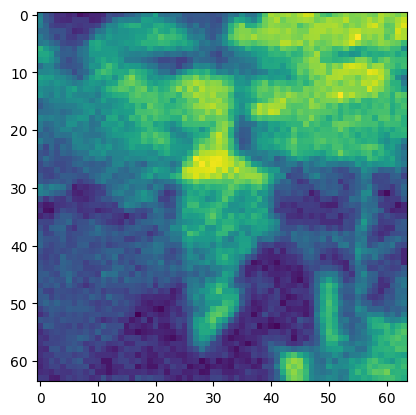

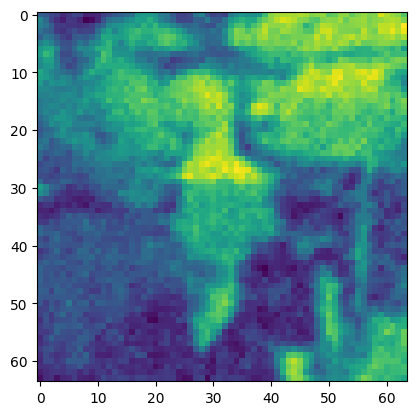

In [12]:
resolution = 64
for name in ["plain_0", "decor_0"]:
    img = np.array(get_img_by_method(f"siren_{name}_img_64", siren_images_df)).reshape(resolution, resolution)
    plt.imshow(img)
    plt.show()

In [7]:
def plot_scatter_baseline_refs(x, ys, labels=None, title="Scatter Plot", xlabel="X", ylabel="Y"):
    """
    Plots a scatter plot with a baseline X and multiple reference Ys.

    Args:
        x (list or np.ndarray): Baseline X values.
        ys (list of lists or np.ndarrays): List of reference Y values.
        labels (list of str, optional): Labels for each Y reference.
        title (str, optional): Plot title.
        xlabel (str, optional): Label for X axis.
        ylabel (str, optional): Label for Y axis.
    """
    plt.figure(figsize=(8, 6))
    for idx, y in enumerate(ys):
        label = labels[idx] if labels and idx < len(labels) else f"Ref {idx+1}"
        plt.scatter(x, y, label=label, s=10)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
def get_betas_by_method(method_name, df):
    row = df[df['Method'] == method_name]
    if not row.empty:
        return row.iloc[0]['Betas']
    return None

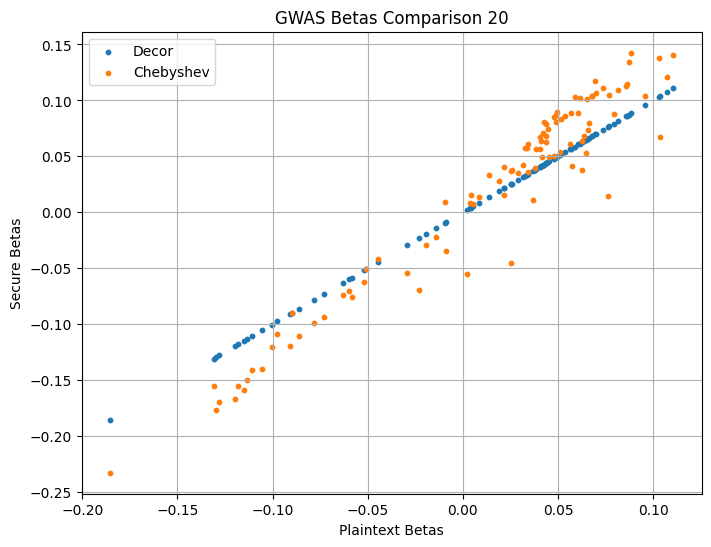

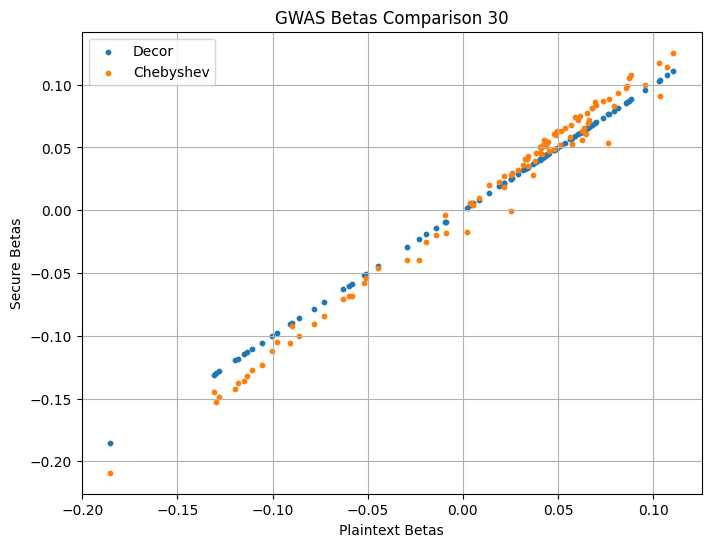

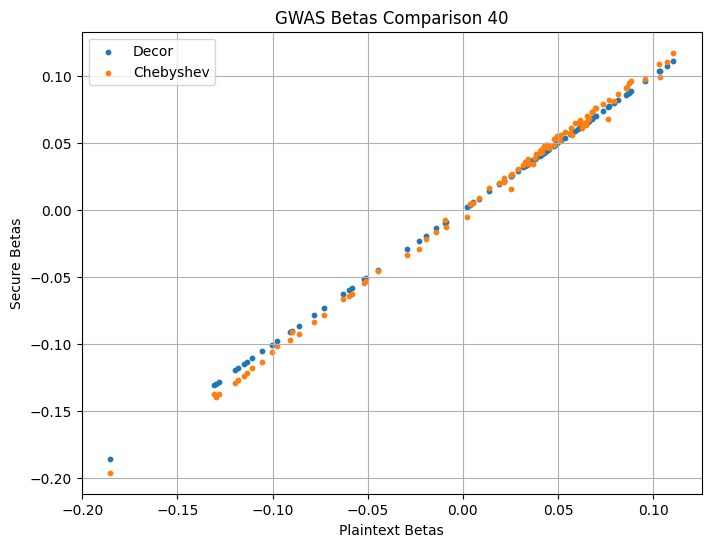

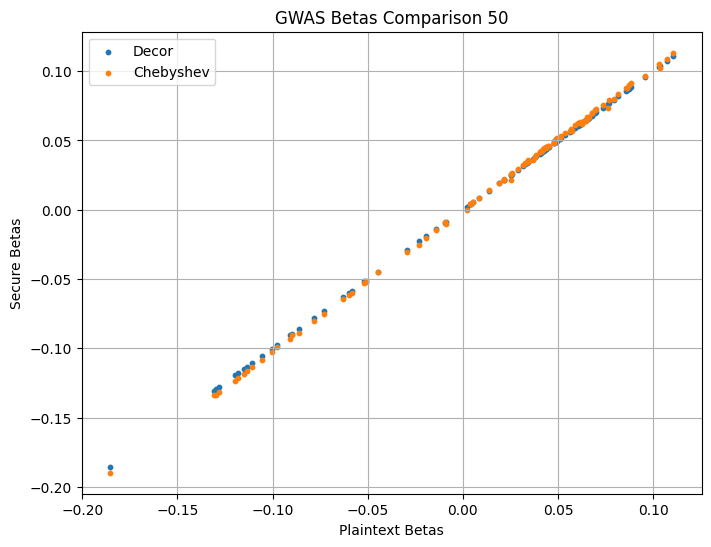

In [9]:
for degree in [20, 30, 40, 50]:
    plot_scatter_baseline_refs(
        x=get_betas_by_method(f"gwas_plaintext_{degree}_betas_64", gwas_betas_df),
        ys=[
            get_betas_by_method(f"gwas_decor_{degree}_betas_64", gwas_betas_df),
            get_betas_by_method(f"gwas_chebyshev_{degree}_betas_64", gwas_betas_df),
        ],
        labels=["Decor", "Chebyshev", "Fourier"],
        title=f"GWAS Betas Comparison {degree}",
        xlabel="Plaintext Betas",
        ylabel="Secure Betas")

In [10]:
e2e_df[e2e_df['Method'].str.contains('gwas')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Loss,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
0,gwas_plaintext_50_64,0.568617,0.675737,0.19028,0,0,0,0
1,gwas_plaintext_30_64,0.568617,0.675737,0.19046,0,0,0,0
8,gwas_plaintext_40_64,0.568617,0.675737,0.21432,0,0,0,0
6,gwas_plaintext_20_64,0.568617,0.675737,0.19041,0,0,0,0
7,gwas_chebyshev_20_64,0.496678,0.680771,11.78493,644437616,4702,1101,1250
4,gwas_chebyshev_30_64,0.466594,0.676725,27.47516,932453616,6702,1601,1750
11,gwas_chebyshev_40_64,0.462784,0.675969,28.81922,1220469616,8702,2101,2250
5,gwas_chebyshev_50_64,0.461220,0.675799,38.50025,1508485616,10702,2601,2750
9,gwas_decor_30_64,0.459850,0.675737,29.21355,1393329616,15002,6301,1050
3,gwas_decor_20_64,0.459848,0.675737,24.47388,1393329616,15002,6301,1050


In [61]:
# e2e_df[e2e_df['Method'].str.contains('multinomial')].sort_values(by='Accuracy', ascending=False)

In [62]:
# e2e_df[e2e_df['Method'].str.contains('dti')].sort_values(by='Accuracy', ascending=False)

In [2]:
import re

def by_name(name, df):
    return df[df['Method'].str.startswith(name)]

def plot_accuracy_vs_perf(
        df, methods=["sin", "cos", "exp", "sigmoid"],
        metric="Runtime (avg)", intervals=["(-20.0, 20.0)"],
        approaches=["decor", "chebyshev", "fourier", "taylor"],
        markers=["o", "s", "^", "v"], colors=["tab:blue", "tab:orange", "tab:green", "tab:red"],
        remove_outliers=False, arangement="horizontal"):
    
    if arangement == "horizontal":
        fig, axs = plt.subplots(1, len(methods), figsize=(5 * len(methods), 5))
    elif arangement == "vertical":
        fig, axs = plt.subplots(len(methods), 1, figsize=(5, 5 * len(methods)))
    elif arangement == "square":
        n = int(np.ceil(np.sqrt(len(methods))))
        fig, axs = plt.subplots(n, n, figsize=(5 * n, 5 * n))
        axs = axs.flatten()
    else:
        raise ValueError(f"Unknown arangement: {arangement}")
    for idx, method in enumerate(methods):
        ax = axs[idx]

        filtered_df = df[df['Method'].str.contains(f"{method}_")]
        filtered_df = filtered_df[
            ~filtered_df['Method'].str.contains('_decor') &
            (~filtered_df['Method'].str.contains('_naive') |
             filtered_df['Method'].str.contains('taylor_'))
        ]
        filtered_df['Method'] = filtered_df['Method'].str.replace(f"{method}_", "", regex=False)
        
        if remove_outliers:
            filtered_df = filtered_df[filtered_df['MAE'] < 0.5]
        
        # Convert MAE to accuracy
        filtered_df['MAE'] = filtered_df['MAE'].apply(lambda x: -math.log2(x))
        
        for interval, group in filtered_df.groupby('Interval'):
            if interval not in intervals:
                print(f"Skipping interval {interval}")
                continue
            for approach, marker, color in zip(approaches, markers, colors):
                for nbit_f in nbit_fs:
                    filtered_group = group[
                        group['Method'].str.startswith(approach) &
                        group['Method'].str.endswith(f"{nbit_f}")
                    ].sort_values(by=[metric, "MAE"])
                    if filtered_group.empty:
                        continue
                    if any(a in approach for a in ["chebyshev", "fourier", "taylor"]):
                        ax.plot(
                            filtered_group[metric], filtered_group["MAE"],
                            label=approach.capitalize(),
                            linestyle='--' if nbit_f == 64 else '-', marker=marker, linewidth=2,
                            color=color
                        )
                        if "chebyshev" in approach:
                            # Add label to each Chebyshev point
                            for x, y, name in zip(filtered_group[metric], filtered_group["MAE"], filtered_group['Method']):
                                # Try to parse first number from the left in approach string
                                match = re.search(r'\d+', name)
                                label = match.group(0) if match else name
                                ax.text(x, y, label, fontsize=8, ha='right', va='bottom')
                    else:
                        ax.scatter(
                            filtered_group[metric], filtered_group["MAE"],
                            label=approach.capitalize(), marker=marker, s=50,
                            color=color
                        )
            ax.set_title(f"{method} at {interval}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Accuracy: -log2(MAE)")
            ax.grid(True)
        if idx == len(methods) - 1:
            ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

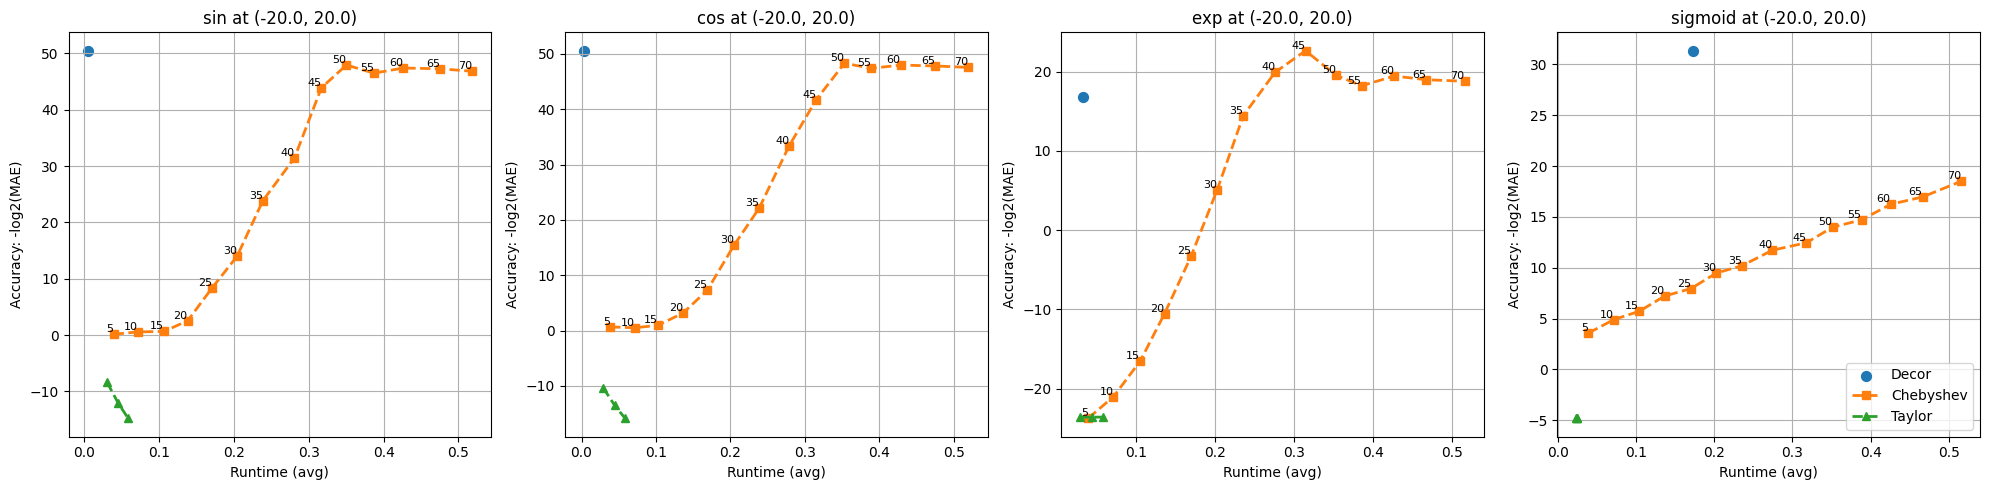

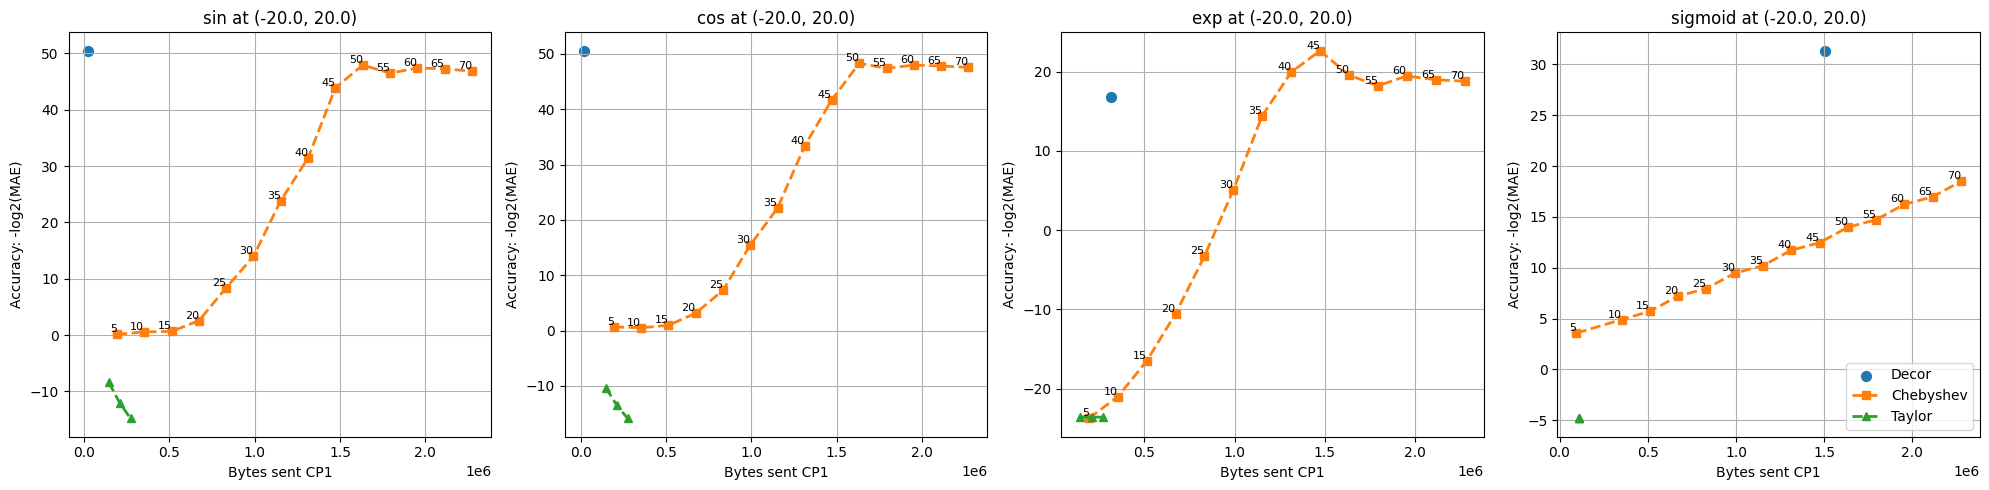

In [ ]:
plot_accuracy_vs_perf(df, metric="Runtime (avg)", approaches=["decor", "chebyshev", "taylor"])
plot_accuracy_vs_perf(df, metric="Bytes sent CP1", approaches=["decor", "chebyshev", "taylor"])

In [ ]:
# Plot sine, square wave, and sawtooth wave results and expected for degree 20, Chebyshev and Fourier

wave_types = ['sin', 'square', 'sawtooth']
degree = 50
methods = ['chebyshev', 'fourier']
colors = ['tab:green', 'tab:orange', 'tab:blue']

fig, axs = plt.subplots(len(wave_types), 1, figsize=(10, 4 * len(wave_types)), sharex=True)

for idx, wave in enumerate(wave_types):
    ax = axs[idx]
    mask = [
            (wave in m) and
            (f'_{degree}' in m)
            for m in df_waves['Method']
        ]
    if not any(mask):
        continue
    x = np.array(df_waves['x'])[mask][0]
    ground_truth = np.array(df_waves['Expected'])[mask][0]
    ax.plot(x, ground_truth, label=f'Ground truth', color=colors[0])
    for i, method in enumerate(methods):
        mask = [
            (wave in m) and
            (method in m) and
            (f'_{degree}' in m)
            for m in df_waves['Method']
        ]
        if not any(mask):
            continue
        result = np.array(df_waves['Result'])[mask][0]
        x = np.array(df_waves['x'])[mask][0]
        ax.plot(
            x, result,
            label=f'{"Decor " if "fourier" in method else ""}{method.capitalize()}',
            linestyle='--', color=colors[i + 1])
    ax.set_title(f'{wave.capitalize()} Wave (Degree {degree})')
    ax.grid(True)
    if idx == 0:
        ax.legend()


plt.xlabel('x')
plt.tight_layout()
plt.show()

In [ ]:
plot_accuracy_vs_perf(
        df, methods=["sin", "square", "sawtooth"],
        metric="Runtime (avg)", intervals=["(-9.42, 9.42)"],
        approaches=["fourier", "chebyshev"], arangement="vertical")
plot_accuracy_vs_perf(
        df, methods=["sin", "square", "sawtooth"],
        metric="Bytes sent CP1", intervals=["(-9.42, 9.42)"],
        approaches=["fourier", "chebyshev"], arangement="vertical")